In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
print('setup complete')

setup complete


In [4]:
calls_data = pd.read_csv('../data/raw/calls.csv')
calls_data.head()

,timestamp,caller,callee,duration
0,184,300,301,121
1,3920,512,299,670
2,5623,301,300,504
3,9252,401,457,-1
4,15466,512,0,5


In [5]:
calls_data.describe()

,timestamp,caller,callee,duration
count,3.600000e+03,3600.000000,3600.000000,3600.000000
mean,1.281670e+06,349.840833,354.581111,56.790833
std,6.662889e+05,226.328594,221.136143,176.862896
min,1.840000e+02,0.000000,0.000000,-1.000000
25%,7.501832e+05,143.000000,163.750000,0.000000
50%,1.250542e+06,335.000000,354.000000,10.000000
75%,1.819620e+06,560.000000,552.000000,50.000000
max,2.416399e+06,846.000000,845.000000,5138.000000


<Axes: xlabel='Duration', ylabel='Frequency'>

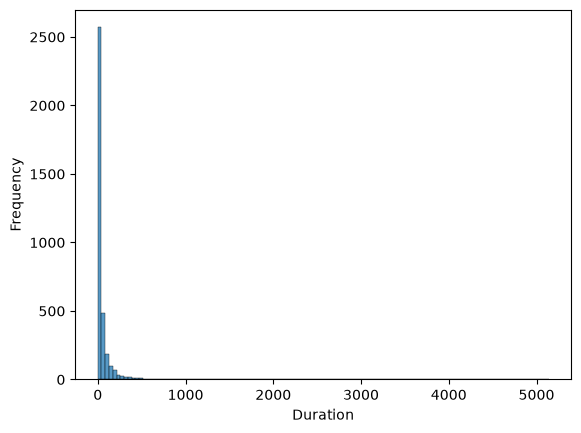

In [6]:
plt.xlabel("Duration")
plt.ylabel("Frequency")


sns.histplot(calls_data['duration'])

/var/folders/1z/1ytnn_3x6qb1l80lchpczlv80000gn/T/ipykernel_27915/1297248608.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=calls_data['duration'], shade=True)


<Axes: xlabel='duration', ylabel='Density'>

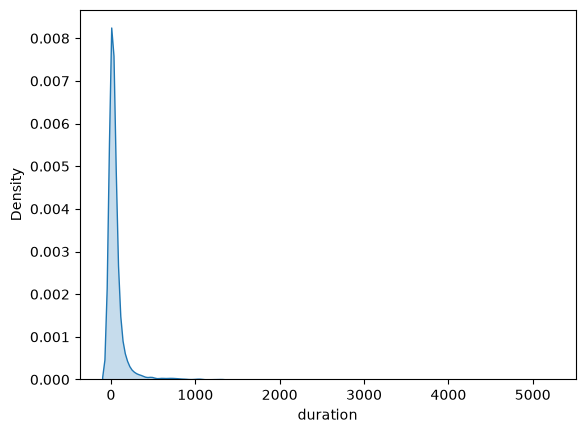

In [7]:
sns.kdeplot(data=calls_data['duration'], shade=True)

## Duration: Extremely right skewed
- maybe we clip to 99 quantile, or just cut it out (team discussion)

<Axes: xlabel='call_pair', ylabel='count'>

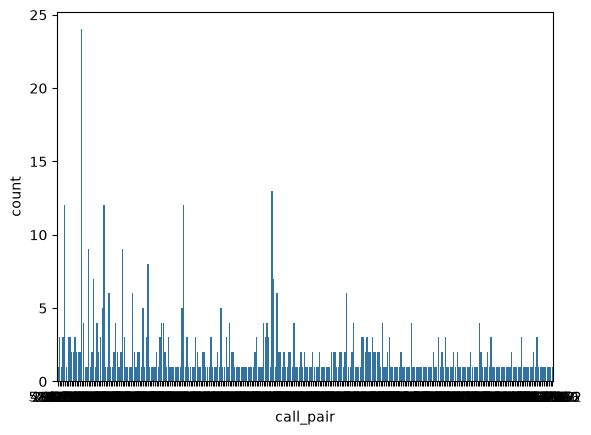

In [8]:
calls_data['call_pair'] = calls_data['caller'].astype(str) + '-' + calls_data['callee'].astype(str)
calls_data['call_pair'] = calls_data[~calls_data['duration']==-1]['call_pair']
sns.countplot(x=calls_data['call_pair'])

<Axes: xlabel='callee', ylabel='count'>

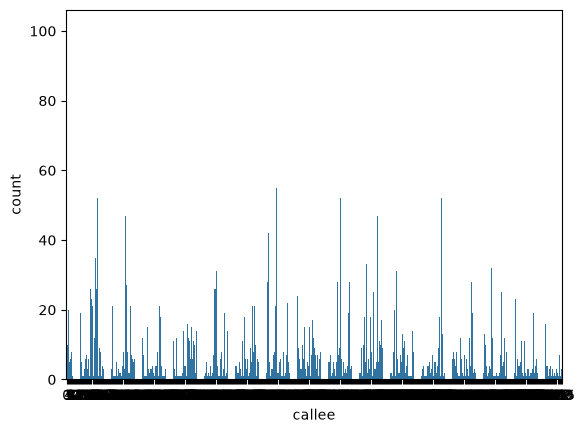

In [9]:
sns.countplot(x=calls_data['callee'])

In [10]:
calls_data.value_counts()

timestamp  caller  callee  duration  call_pair
38151      584     582     0         584-582      1
40307      480     210     0         480-210      1
46698      267     269     0         267-269      1
65878      12      13      0         12-13        1
69794      12      13      0         12-13        1
                                                 ..
2324367    534     360     0         534-360      1
2330989    354     666     0         354-666      1
2366001    558     162     0         558-162      1
2371597    661     683     0         661-683      1
2378590    21      20      0         21-20        1
Name: count, Length: 580, dtype: int64

In [13]:
df_bt = pd.read_csv('../data/raw/bt_symmetric.csv')

8064
0 0
1 300
2 600


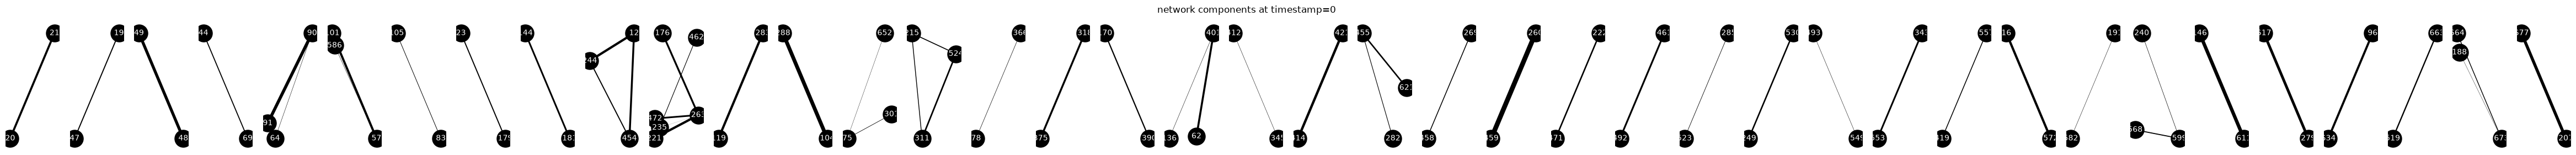

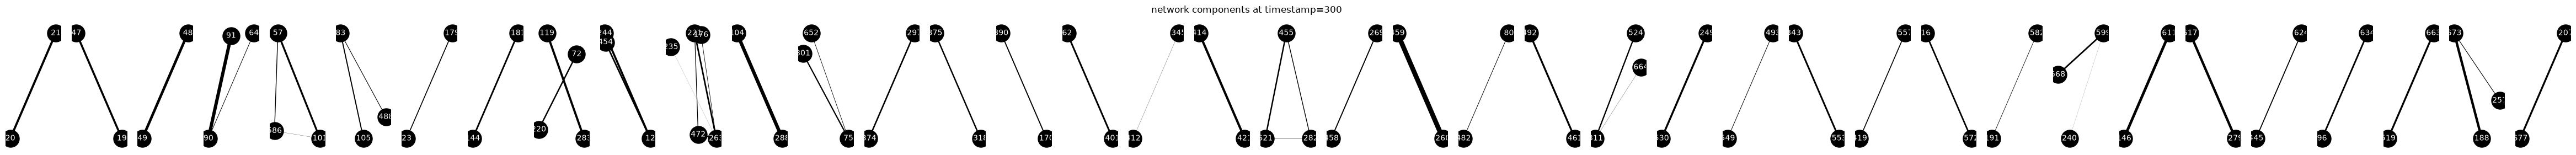

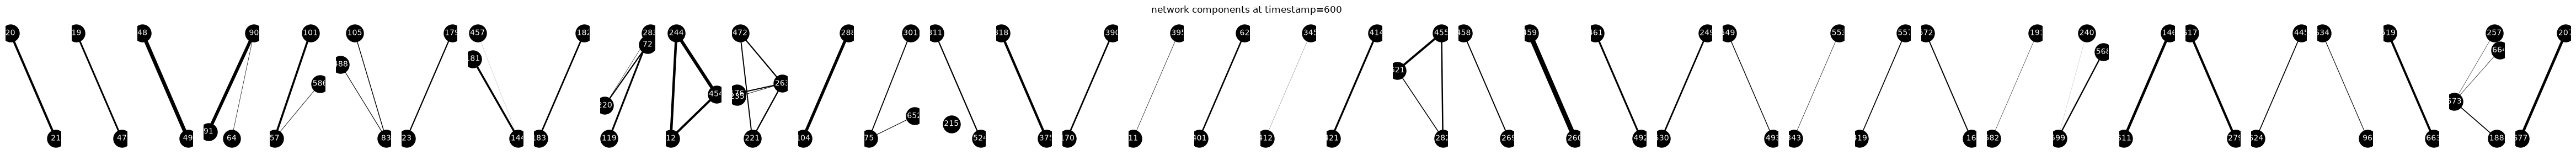

In [23]:
def VisualizeBluetoothNetwork(df_bt, timestamp):
  """ Plots each connected component in |df_bt| network at |timestamp|."""
  # NetworkX graph to plot the results.
  G = nx.Graph()

  # In-study users (id >= 0) at given timestamp.
  in_study_users_at_timestamp = df_bt[(df_bt["# timestamp"] == timestamp)
                                      & (df_bt["user_b"] >= 0)][[
                                          "user_a", "user_b", "rssi"
                                      ]]

  # Builds an undirected network of the in-study users.
  for row in in_study_users_at_timestamp.itertuples():
    user_a = row[1]
    user_b = row[2]
    rssi = row[3]
    G.add_edge(user_a, user_b, weight=rssi)

# For clarity, we consider each connected component separately.  
  connected_components = [G.subgraph(c).copy() for c in nx.connected_components(G)]
  fig, axs = plt.subplots(1, len(connected_components), figsize=(60, 3))
  
  # Plots the connected components of the network.
  fig.suptitle("network components at timestamp={}".format(timestamp))
  [
      nx.draw(
          connected_component,
          # Positions of nodes are calculatued using spring layout.
          pos=nx.spring_layout(connected_component, scale=0.2),
          ax=axs[i],
          # Width of the edges is based on higher RSSI = stronger edge.
          width=[(100 + connected_component[u][v]["weight"]) / 10.0
                 for u, v in connected_component.edges()],
          node_size=500,
          node_color="black",
          with_labels=True,
          font_size=10,
          font_color="white")
      for i, connected_component in enumerate(connected_components)
  ]

timestamps = df_bt["# timestamp"].unique()
print(len(timestamps))
for i in range(3):
    print(i, timestamps[i])
    VisualizeBluetoothNetwork(df_bt, timestamps[i])
